## 1. Imports and Setup

This cell imports all the necessary libraries for data manipulation, machine learning, and evaluation.

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

## 2. Load Dataset

We'll load the `Datas.csv` file, which is the PaySim dataset, into a pandas DataFrame. This dataset contains synthetic financial transaction data.

In [80]:
df = pd.read_csv('/content/Datas.csv')
print(f"Dataset loaded with shape: {df.shape}")
display(df.head())

Dataset loaded with shape: (219765, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


## 3. Filter and Feature Engineering

In this step, we focus on relevant transaction types and engineer new features that can help the model detect fraud. Fraud is known to occur exclusively within 'TRANSFER' and 'CASH_OUT' transaction types. We also create `errorBalanceOrig` and `errorBalanceDest` to capture discrepancies in account balances, which are strong indicators of fraudulent activity.

In [81]:
df = pd.read_csv('/content/Datas.csv')

# Keep only TRANSFER and CASH_OUT types where fraud occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Create accounting discrepancy features
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print("Dataset after filtering and feature engineering:")
display(df.head())

Dataset after filtering and feature engineering:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,0.00,181.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,0.00,21363.0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,213808.94,182703.5
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,214605.30,237735.3
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,300850.89,-2401220.0


## 4. Data Cleaning and Encoding

Here, we perform necessary data cleaning by dropping irrelevant columns such as unique IDs (`nameOrig`, `nameDest`), a potentially redundant flag (`isFlaggedFraud`), and `step` (which represents time and may not be directly useful for this model). Finally, we one-hot encode the `type` column to convert categorical data into a numerical format suitable for machine learning models.

In [82]:
# Drop unique IDs, timestamps, and old rule columns
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud', 'step'])

# One-hot encode the transaction type column into numeric format
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

print("Dataset after cleaning and encoding:")
display(df.head())

Dataset after cleaning and encoding:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_TRANSFER
2,181.00,181.0,0.0,0.0,0.00,1.0,0.00,181.0,1
3,181.00,181.0,0.0,21182.0,0.00,1.0,0.00,21363.0,0
15,229133.94,15325.0,0.0,5083.0,51513.44,0.0,213808.94,182703.5,0
19,215310.30,705.0,0.0,22425.0,0.00,0.0,214605.30,237735.3,1
24,311685.89,10835.0,0.0,6267.0,2719172.89,0.0,300850.89,-2401220.0,1


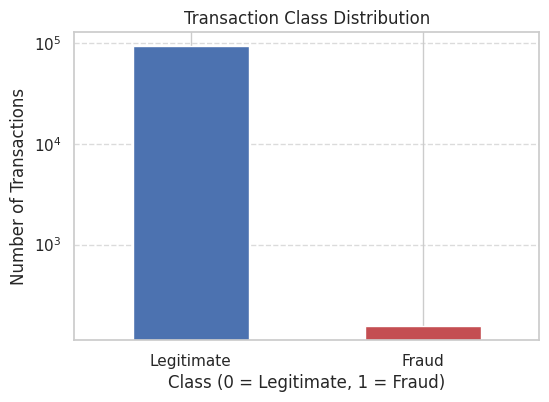

In [94]:
import matplotlib.pyplot as plt

# Plot a simple bar chart of the target variable
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6, 4))
fraud_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Transaction Class Distribution')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraud'], rotation=0)
plt.yscale('log') # Log scale helps visualize the massive difference
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Train-Test Split and Class Weight Ratio Calculation

This section prepares the data for model training by splitting it into training and testing sets. A stratified split is crucial here to ensure that the proportion of fraudulent transactions is maintained in both sets, given the severe class imbalance. We also calculate a `scale_pos_weight` ratio, which will be used by the XGBoost model to give more importance to the minority class (fraudulent transactions) during training, helping to address the imbalance.

In [95]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Stratified split to preserve the exact fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Calculate the imbalance multiplier so the model prioritizes rare fraud cases
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Class imbalance ratio (non-fraud / fraud): {ratio:.2f}")

Shape of X_train: (73953, 8)
Shape of y_train: (73953,)
Shape of X_test: (18489, 8)
Shape of y_test: (18489,)
Class imbalance ratio (non-fraud / fraud): 595.40


## 6. Model Training (XGBoost)

We train an XGBoost Classifier, a powerful gradient boosting framework, using the training data. The `scale_pos_weight` parameter, calculated in the previous step, is passed to the model to handle the class imbalance effectively.

In [96]:
model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train the model on the training set
model.fit(X_train, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


## 7. Model Evaluation

Finally, we evaluate the trained XGBoost model's performance on the unseen test set. We use common classification metrics such as the classification report (which includes precision, recall, and F1-score) and the ROC-AUC score to assess how well the model identifies fraudulent transactions.

In [97]:
# Predict classes and probabilities on the unseen test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print out results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     18458
         1.0       0.84      1.00      0.91        31

    accuracy                           1.00     18489
   macro avg       0.92      1.00      0.96     18489
weighted avg       1.00      1.00      1.00     18489

ROC-AUC Score: 0.9999729114746992


## 8. Model Saving
Store the trained model on disk so it doesn't need to be retrained every time you want to use it.Easily load the model in a new session or application to make predictions on new, unseen data.This saved model can then be deployed to a production environment for real-time fraud detection.

In [98]:
import joblib
joblib.dump(model, 'Saved Model.pkl')
print("Model successfully saved as 'Saved Model.pkl'")
# To load the model later in another session or script:
# loaded_model = joblib.load('fraud_detector_model.pkl')

Model successfully saved as 'Saved Model.pkl'
